In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme

import nsEVDx as ns

#### Generating time series of non-stationary extremes


['B0 (location intercept)', 'B1 (location slope for covariate 1)', 'sigma (scale)', 'xi (shape)']


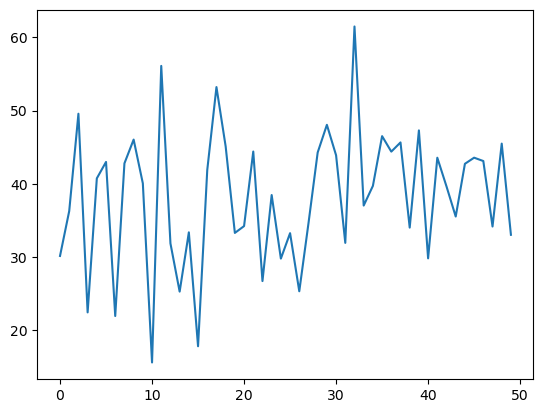

In [2]:
np.random.seed(112)
config = [1, 0, 0]
# location parameter is non-stationary and scale and shape parameters are stationary
# See Usage.md or https://nischalcs50.github.io/nsEVDx/ for more details on config
# checking the parameters corresponding to the config

print(ns.NonStationaryEVD.get_param_description(config=config, n_cov=1))
# checking the parameters corresponding to the config

params = [30, 0.2, 8, 0.15]  # setting the parameters for the non-stationary EVD model
cov = np.array(range(50))  # Generating a covariate that increases linearly with time
data = ns.NonStationaryEVD.ns_EVDrvs(genextreme, params, cov, config, size=50)

plt.plot(data)  # plotting the time serie of extremes tat increases linearly

#### Setting Piors

In [3]:
# Priors: normal for regression coefficients of location parameter,
#         half-normal for scale, normal for shape
prior_specs = [
    ("normal", {"loc": 30, "scale": 10}),
    ("normal", {"loc": 0, "scale": 1}),
    ("halfnormal", {"loc": 5, "scale": 5}),
    ("normal", {"loc": 0, "scale": 0.4}),
]
sampler = ns.NonStationaryEVD(
    config, data, cov, dist=genextreme, prior_specs=prior_specs
)
print(sampler.descriptions)

['B0 (location intercept)', 'B1 (location slope for covariate 1)', 'sigma (scale)', 'xi (shape)']


#### Running Bayesian algorithm to sample posterior distribution of parameters

In [4]:
# fitting a non-stationary GEV model to the data using
# Hamiltonian Monte Carlo (HMC) sampler

# Leave the line just below commented if you are not debugging
# logger.debug("Prior %s returned invalid logpdf...", ptype, param_idx, val, kwargs)
initial_params = [30, 0, 7, 0.1]
samples, a_rate = sampler.MH_Hmc(
    num_samples=3000, initial_params=initial_params, step_size=0.005, T=5
)

#### Print results

In [5]:
print(f"acceptance_rate : {a_rate}")
np.set_printoptions(suppress=True, precision=6)
burn_in = 500
print(f"Sample mean : {samples[:burn_in, :].mean(axis=0)}")

acceptance_rate : 0.434
Sample mean : [30.276985  0.172848  8.185971  0.193517]


#### Plot Convergence & Posterior Distributions

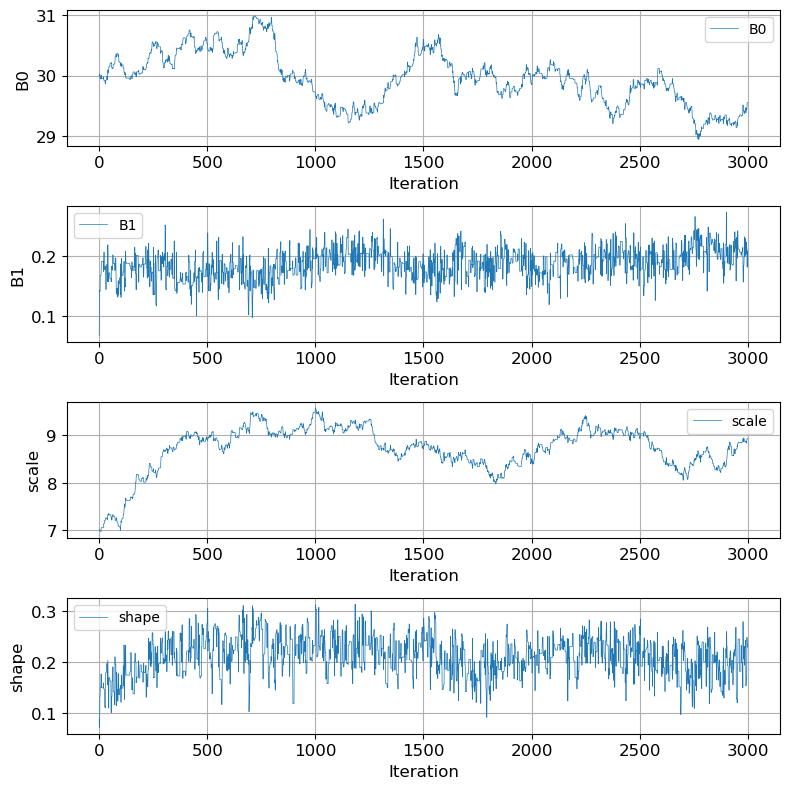

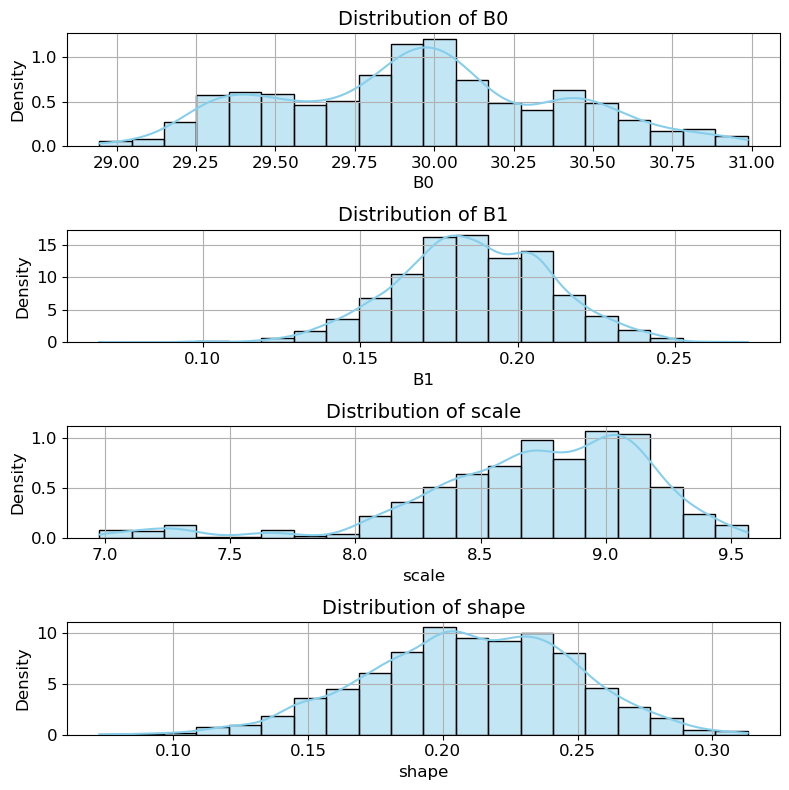

In [6]:
ns.plot_trace(samples, config, fig_size=(8, 8))
ns.plot_posterior(samples, config, fig_size=(8, 8))